### **Introduction**
Goal is to predict a continuous grammar score (0 to 5) directly from spoken audio.

In [1]:
import os
import warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm
from scipy.stats import pearsonr

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
np.random.seed(42)

In [2]:
@dataclass
class CFG:
    base_dir: Path = Path("/kaggle/input/competitions/shl-audio-scoring-challenge/dataset") 
    train_csv: Path = base_dir / "csvs" / "train.csv"
    test_csv: Path = base_dir / "csvs" / "test.csv"
    train_audio_dir: Path = base_dir / "audios" / "train"
    test_audio_dir: Path = base_dir / "audios" / "test"

    sample_rate: int = 16000
    n_mfcc: int = 20
    n_splits: int = 5
    random_state: int = 42

    hybrid_alpha: float = 0.65

    cache_dir: Path = Path("/kaggle/working/")
    train_feat_cache: Path = cache_dir / "train_features.csv"
    test_feat_cache: Path = cache_dir / "test_features.csv"
    submission_path: Path = cache_dir / "submission_v2.csv"

In [3]:
cfg = CFG()
cfg.cache_dir.mkdir(parents=True, exist_ok=True)
print(cfg)

CFG(base_dir=PosixPath('/kaggle/input/competitions/shl-audio-scoring-challenge/dataset'), train_csv=PosixPath('/kaggle/input/competitions/shl-audio-scoring-challenge/dataset/csvs/train.csv'), test_csv=PosixPath('/kaggle/input/competitions/shl-audio-scoring-challenge/dataset/csvs/test.csv'), train_audio_dir=PosixPath('/kaggle/input/competitions/shl-audio-scoring-challenge/dataset/audios/train'), test_audio_dir=PosixPath('/kaggle/input/competitions/shl-audio-scoring-challenge/dataset/audios/test'), sample_rate=16000, n_mfcc=20, n_splits=5, random_state=42, hybrid_alpha=0.65, cache_dir=PosixPath('/kaggle/working'), train_feat_cache=PosixPath('/kaggle/working/train_features.csv'), test_feat_cache=PosixPath('/kaggle/working/test_features.csv'), submission_path=PosixPath('/kaggle/working/submission_v2.csv'))


In [4]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def pearson_safe(y_true, y_pred):
    if np.std(y_pred) == 0 or np.std(y_true) == 0:
        return 0.0
    return float(pearsonr(y_true, y_pred)[0])

def hybrid_score(y_true, y_pred, alpha=0.65):
    r = rmse(y_true, y_pred)
    p = pearson_safe(y_true, y_pred)
    return alpha * r + (1 - alpha) * (1 - p)

### **Data**
Train set has 409 labeled samples and test set has 197 samples.
Audio files are matched by filename from the provided folders.

In [5]:
train_df = pd.read_csv(cfg.train_csv)
test_df = pd.read_csv(cfg.test_csv)

In [6]:
print("train:", train_df.shape, "test:", test_df.shape)
display(train_df.head())

train: (409, 2) test: (197, 1)


,filename,label
0,audio_173,3.0
1,audio_138,3.0
2,audio_127,2.0
3,audio_95,2.0
4,audio_73,3.5


### **Preprocessing**
All audio is loaded at 16 kHz to keep feature extraction consistent across files.
No manual trimming/padding was applied in this version.

In [7]:
def summarize(prefix, arr):
    arr = np.asarray(arr, dtype=np.float32)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return {
            f"{prefix}_mean": np.nan, f"{prefix}_std": np.nan, f"{prefix}_min": np.nan,
            f"{prefix}_max": np.nan, f"{prefix}_p10": np.nan, f"{prefix}_p50": np.nan, f"{prefix}_p90": np.nan
        }
    return {
        f"{prefix}_mean": float(np.mean(arr)),
        f"{prefix}_std": float(np.std(arr)),
        f"{prefix}_min": float(np.min(arr)),
        f"{prefix}_max": float(np.max(arr)),
        f"{prefix}_p10": float(np.percentile(arr, 10)),
        f"{prefix}_p50": float(np.percentile(arr, 50)),
        f"{prefix}_p90": float(np.percentile(arr, 90)),
    }

In [8]:
def find_audio_file(audio_dir: Path, stem: str):
    for ext in [".wav"]:
        p = audio_dir / f"{stem}{ext}"
        if p.exists():
            return p
    return None

### **Feature Extraction**
Used handcrafted audio features: MFCCs (+ delta, delta2), pitch-related stats, RMS/pauses, and spectral descriptors.
This gives a richer representation than MFCC mean/std alone.

In [9]:
def extract_features_from_file(path: Path, sr=16000, n_mfcc=20):
    y, sr = librosa.load(path, sr=sr, mono=True)
    feats = {"duration_sec": len(y) / sr}

    rms = librosa.feature.rms(y=y)[0]
    feats.update(summarize("rms", rms))
    silence_thr = np.percentile(rms, 15)
    feats["pause_ratio"] = float(np.mean(rms <= silence_thr))

    zcr = librosa.feature.zero_crossing_rate(y=y)[0]
    feats.update(summarize("zcr", zcr))

    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
    flatness = librosa.feature.spectral_flatness(y=y)[0]

    feats.update(summarize("centroid", centroid))
    feats.update(summarize("bandwidth", bandwidth))
    feats.update(summarize("rolloff", rolloff))
    feats.update(summarize("flatness", flatness))

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    d1 = librosa.feature.delta(mfcc)
    d2 = librosa.feature.delta(mfcc, order=2)

    for i in range(n_mfcc):
        feats[f"mfcc_{i+1}_mean"] = float(np.mean(mfcc[i]))
        feats[f"mfcc_{i+1}_std"] = float(np.std(mfcc[i]))
        feats[f"mfcc_d1_{i+1}_mean"] = float(np.mean(d1[i]))
        feats[f"mfcc_d1_{i+1}_std"] = float(np.std(d1[i]))
        feats[f"mfcc_d2_{i+1}_mean"] = float(np.mean(d2[i]))
        feats[f"mfcc_d2_{i+1}_std"] = float(np.std(d2[i]))

    try:
        f0, voiced_flag, _ = librosa.pyin(y, fmin=75, fmax=450, sr=sr)
        voiced = np.isfinite(f0)
        feats["voiced_ratio"] = float(np.mean(voiced))
        feats.update(summarize("f0", f0[voiced] if voiced.any() else np.array([])))
    except Exception:
        feats["voiced_ratio"] = np.nan
        feats.update(summarize("f0", np.array([])))

    return feats

In [10]:
def build_feature_table(df, audio_dir, is_train=True):
    rows = []
    missing = 0
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Extracting @ {audio_dir}"):
        stem = str(row["filename"])
        p = find_audio_file(audio_dir, stem)
        if p is None:
            missing += 1
            rec = {"filename": stem}
        else:
            rec = {"filename": stem, **extract_features_from_file(p, cfg.sample_rate, cfg.n_mfcc)}
        if is_train:
            rec["label"] = float(row["label"])
        rows.append(rec)
    out = pd.DataFrame(rows)
    print(f"Missing audio files: {missing}")
    return out

In [11]:
if cfg.train_feat_cache.exists():
    train_feat = pd.read_csv(cfg.train_feat_cache)
else:
    train_feat = build_feature_table(train_df, cfg.train_audio_dir, is_train=True)
    train_feat.to_csv(cfg.train_feat_cache, index=False)

if cfg.test_feat_cache.exists():
    test_feat = pd.read_csv(cfg.test_feat_cache)
else:
    test_feat = build_feature_table(test_df, cfg.test_audio_dir, is_train=False)
    test_feat.to_csv(cfg.test_feat_cache, index=False)

print("train_feat:", train_feat.shape, "test_feat:", test_feat.shape)

Extracting @ /kaggle/input/competitions/shl-audio-scoring-challenge/dataset/audios/train:   0%|          | 0/4…

Missing audio files: 0


Extracting @ /kaggle/input/competitions/shl-audio-scoring-challenge/dataset/audios/test:   0%|          | 0/19…

Missing audio files: 0
train_feat: (409, 174) test_feat: (197, 173)


In [12]:
X = train_feat.drop(columns=["filename", "label"])
y = train_feat["label"].values
X_test = test_feat.drop(columns=["filename"])

In [13]:
# bins for stratified regression split
y_bins = pd.qcut(y, q=min(8, len(np.unique(y))), labels=False, duplicates="drop")

### **Models Tried**
Trained Ridge, ElasticNet, RandomForest, ExtraTrees, and HistGradientBoosting.
Compared them using RMSE, Pearson, and a hybrid proxy metric.

In [14]:
models = {
    "ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=3.0, random_state=cfg.random_state)),
    ]),
    "elastic": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.002, l1_ratio=0.2, random_state=cfg.random_state)),
    ]),
    "rf": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(n_estimators=800, min_samples_leaf=2, random_state=cfg.random_state, n_jobs=-1)),
    ]),
    "extra": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesRegressor(n_estimators=1200, min_samples_leaf=2, random_state=cfg.random_state, n_jobs=-1)),
    ]),
    "hgb": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", HistGradientBoostingRegressor(max_depth=8, learning_rate=0.02, max_iter=900, random_state=cfg.random_state)),
    ]),
}

### **Validation Strategy**
Used 5-fold stratified CV (with label bins) and generated out-of-fold predictions.
This gives a more reliable estimate than a single train/validation split.

In [15]:
skf = StratifiedKFold(n_splits=cfg.n_splits, shuffle=True, random_state=cfg.random_state)

In [16]:
oof = {k: np.zeros(len(X)) for k in models}
fold_rows = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y_bins), 1):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]

    for name, model in models.items():
        model.fit(X_tr, y_tr)
        pred = model.predict(X_va)
        oof[name][va_idx] = pred

        fold_rows.append({
            "fold": fold,
            "model": name,
            "rmse": rmse(y_va, pred),
            "pearson": pearson_safe(y_va, pred),
            "hybrid": hybrid_score(y_va, pred, cfg.hybrid_alpha),
        })

In [17]:
cv_df = pd.DataFrame(fold_rows)
display(cv_df.groupby("model")[["rmse", "pearson", "hybrid"]].mean().sort_values("hybrid"))

,rmse,pearson,hybrid
model,,,
hgb,0.657243,0.520192,0.595141
extra,0.667566,0.493628,0.611148
rf,0.678073,0.471883,0.625588
ridge,0.877725,0.333510,0.803792
elastic,0.895953,0.310670,0.823635


Built a weighted ensemble from OOF predictions.
Learned weights mostly favored HGB and ExtraTrees.

### **Final OOF Metrics**

In [18]:
from scipy.optimize import minimize

model_names = list(models.keys())
P = np.column_stack([oof[m] for m in model_names])

In [19]:
def objective(w):
  pred = P @ w
  return hybrid_score(y, pred, cfg.hybrid_alpha)

In [20]:
w0 = np.ones(len(model_names)) / len(model_names)
bounds = [(0.0, 1.0)] * len(model_names)
cons = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]

res = minimize(objective, w0, method="SLSQP", bounds=bounds, constraints=cons)
weights = res.x if res.success else w0

In [21]:
oof_ens = P @ weights
print("ensemble weights:", dict(zip(model_names, np.round(weights, 4))))
print("OOF RMSE:", round(rmse(y, oof_ens), 5))
print("OOF Pearson:", round(pearson_safe(y, oof_ens), 5))
print("OOF Hybrid:", round(hybrid_score(y, oof_ens, cfg.hybrid_alpha), 5))

ensemble weights: {'ridge': np.float64(0.0172), 'elastic': np.float64(0.0), 'rf': np.float64(0.0), 'extra': np.float64(0.3814), 'hgb': np.float64(0.6015)}
OOF RMSE: 0.65144
OOF Pearson: 0.52638
OOF Hybrid: 0.58921


* Ensemble OOF RMSE: `0.65144`
* Ensemble OOF Pearson: `0.52638`
* Ensemble OOF Hybrid: `0.58921`

### **Single-Model Results**

In [22]:
best_single = cv_df.groupby("model")["hybrid"].mean().idxmin()
print("Best single model:", best_single)

Best single model: hgb


* Best single model was HistGradientBoosting (`max_depth=8`, `learning_rate=0.02`, `max_iter=900`).
* Mean CV: RMSE `0.6572`, Pearson `0.5202`, Hybrid `0.5951`.

### **Data Visualization**

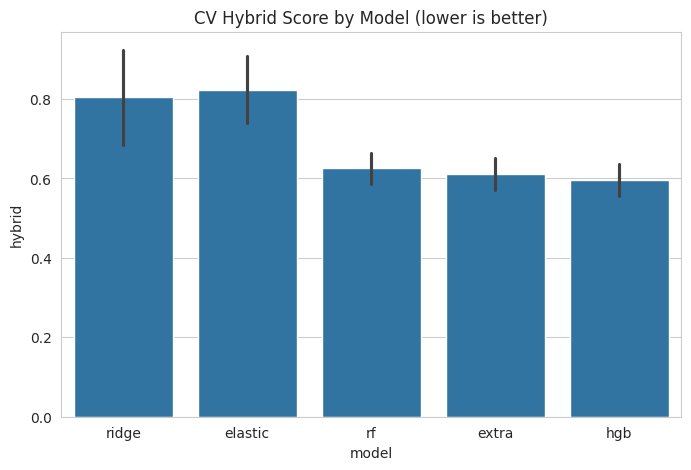

In [23]:
plt.figure(figsize=(8, 5))
sns.barplot(data=cv_df, x="model", y="hybrid", estimator=np.mean, errorbar="sd")
plt.title("CV Hybrid Score by Model (lower is better)")
plt.show()

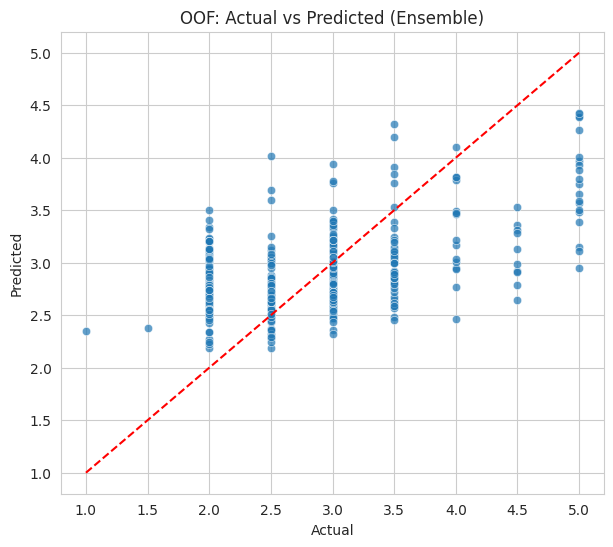

In [24]:
resid = y - oof_ens
plt.figure(figsize=(7, 6))
sns.scatterplot(x=y, y=oof_ens, alpha=0.7)
mn, mx = min(y.min(), oof_ens.min()), max(y.max(), oof_ens.max())
plt.plot([mn, mx], [mn, mx], "r--")
plt.title("OOF: Actual vs Predicted (Ensemble)")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

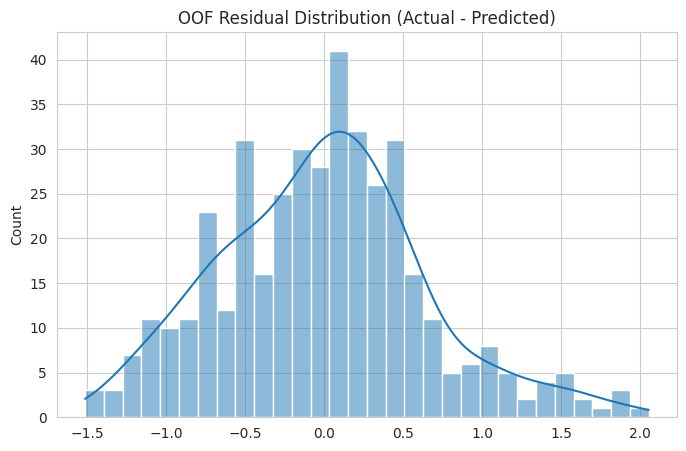

In [25]:
plt.figure(figsize=(8, 5))
sns.histplot(resid, bins=30, kde=True)
plt.title("OOF Residual Distribution (Actual - Predicted)")
plt.show()

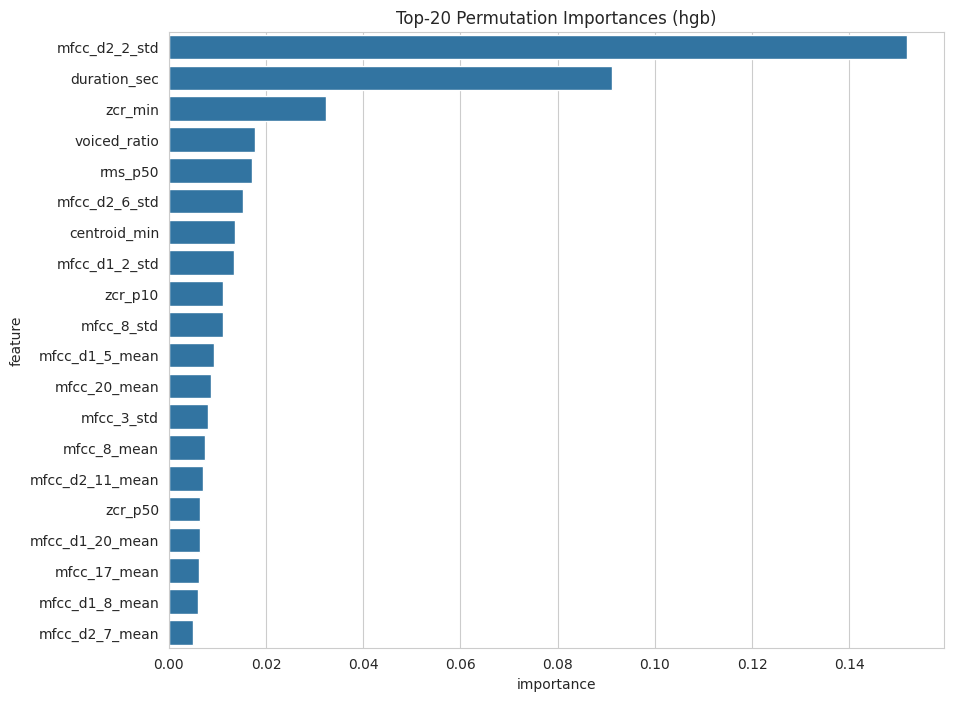

In [26]:
#permutation importance on best single model fitted to all train data
final_best = models[best_single]
final_best.fit(X, y)
pi = permutation_importance(final_best, X, y, n_repeats=8, random_state=cfg.random_state, n_jobs=-1)
imp = pd.DataFrame({"feature": X.columns, "importance": pi.importances_mean}).sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=imp, y="feature", x="importance")
plt.title(f"Top-20 Permutation Importances ({best_single})")
plt.show()

### **Prediction on Test Set**

In [27]:
test_preds_by_model = {}
for name, model in models.items():
    model.fit(X, y)
    test_preds_by_model[name] = model.predict(X_test)

test_stack = np.column_stack([test_preds_by_model[m] for m in model_names])
test_pred_ens = test_stack @ weights
test_pred_ens = np.clip(test_pred_ens, 0, 5)

In [28]:
submission = pd.DataFrame({
    "filename": test_feat["filename"],
    "label": test_pred_ens
})
submission.to_csv(cfg.submission_path, index=False)
print("Saved:", cfg.submission_path)
display(submission.head())

Saved: /kaggle/working/submission_v2.csv


,filename,label
0,audio_141,2.566678
1,audio_114,2.809233
2,audio_17,2.672374
3,audio_76,3.478058
4,audio_156,2.866487


### **Final Inference**
For submission, all models are refit on full training data, test predictions are ensembled, then clipped to [0, 5].
Final file is saved as submission.csv

### **Notes**
This is still an audio-only approach, so grammar is inferred indirectly through speech patterns.
Further gains may come from adding pretrained speech embeddings and stronger ensembling.